In [1]:
import os
import numpy as np
import glob
import xarray as xr
import museval
from museval.utils import get_response, find_response, aia_synthesis, wavelength_in_cube
from muse.synthesis.synthesis import transform_resp_units
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import re
from pathlib import Path
from astropy.time import Time
from museval.io import create_session, is_complete, extract_remote_str, files_to_retry
import sunpy.map
import sunpy.visualization.colormaps as cm
import eispac
import astropy.units as u
from astropy.coordinates import SkyCoord
from aiapy.psf import deconvolve, psf
from tqdm import tqdm
from scipy.ndimage import zoom ## Zoom from scipy does all and more than congrid in IDL

In [2]:
## QS VDEM synthesis
os.environ['VDEM_path'] = '/Users/souvikb/MUSE_outputs/vdems/'
vdem_file = os.path.join(os.environ['VDEM_path'], 'muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr')
qs_vdem = xr.open_zarr(vdem_file)
os.environ['RESPONSE'] = '/Users/souvikb/MUSE_outputs/response/new_response/'
work_dir = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/'
# date_sensitive = True
units = 'DN'
channels = [131,171,193,211] # for the Synthetic AIA channels
os.environ['aia_npz_data'] = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/'
str_prefix_npz = 'QS_AIA_'
aia_data_npz = sorted(glob.glob(os.environ['aia_npz_data'] + str_prefix_npz + '*.npz'))


for idx, file in tqdm(enumerate(sorted(aia_data_npz))):
    s = file
    stem = Path(s).stem # gives the filename without directory path and without the final extension
    m = re.search(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", stem) # scans stem for a datetime pattern like YYYY-MM-DDTHH:MM:SS
    dt_str = m.group(0) if m else None

    ## Begin the Response function and AIA synthesis section 
    date = Time(dt_str,format='isot',scale='utc') # astropy time object
    print(f' Date Sensitive AIA {units} Response from {date.strftime("%b %y")}')
    aia_resp = get_response(qs_vdem, date = date, save_response = True) # creating AIA response functions on the fly
    muse_AIA_QS = aia_synthesis(aia_resp, work_dir, vdem_file, swap_dims = False) # Synthesizing AIA QS data from VDEM
    


0it [00:00, ?it/s]

 Date Sensitive AIA DN Response from Apr 14
2026-03-30 16:30:56.287 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 0 months from obs_date 
2026-03-30 16:30:56.288 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Apr14.zarr already exists! Reading...
2026-03-30 16:30:56.498 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-03-30 16:30:56.498 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-03-30 16:30:56.499 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


1it [00:00,  2.16it/s]

 Date Sensitive AIA DN Response from Mar 16
2026-03-30 16:30:56.743 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 7 months from obs_date 
2026-03-30 16:30:56.743 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Aug15.zarr already exists! Reading...
2026-03-30 16:30:56.763 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-03-30 16:30:56.764 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-03-30 16:30:56.764 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


2it [00:00,  2.99it/s]

...

3it [00:00,  3.49it/s]

 Date Sensitive AIA DN Response from Aug 19
2026-03-30 16:30:57.216 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 7 months from obs_date 
2026-03-30 16:30:57.217 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Jan19.zarr already exists! Reading...
2026-03-30 16:30:57.234 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-03-30 16:30:57.234 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-03-30 16:30:57.234 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


4it [00:01,  3.76it/s]

 Date Sensitive AIA DN Response from Dec 19
2026-03-30 16:30:57.450 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 11 months from obs_date 
2026-03-30 16:30:57.450 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Jan19.zarr already exists! Reading...
2026-03-30 16:30:57.465 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-03-30 16:30:57.466 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-03-30 16:30:57.466 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


5it [00:01,  3.56it/s]


In [5]:
scale_sim = (muse_AIA_QS.flux.y[1]-muse_AIA_QS.flux.y[0])*1e-2*1e-3

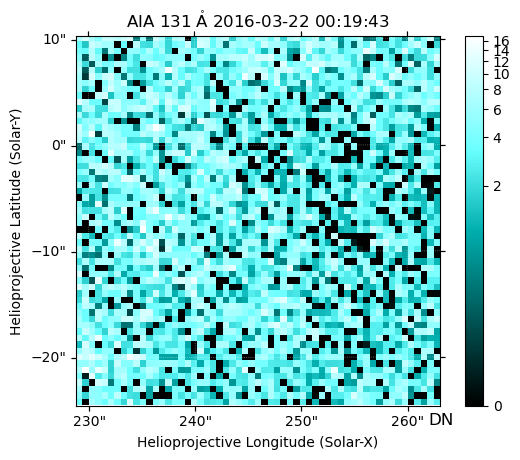

In [2]:
test_dpath = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2016-03-22T00:18:40'+'/bigger_sdo_cutouts/'
test_cut_out_map = sunpy.map.Map(test_dpath + 'aia.lev1_euv_12s.2016-03-22T001945Z.131.image_lev1.fits')
test_cut_out_map.peek()

In [72]:
test_cut_out_map.wavelength.value
mag_cut_out = sunpy.map.Map(test_dpath+'hmi.m_45s.20191201_162445_TAI.2.magnetogram.fits')
# mag_cut_out.peek()
# if mag_cut_out.wavelength.value != None:
#     print("\n Bang on")
# else: print("\n Not Bang on")


In [6]:
from scipy.ndimage import zoom ## Zoom from scipy does all and more than congrid in IDL
data_sim = muse_AIA_QS.flux.sel(channel=171).squeeze().data
aia_scale_x = test_cut_out_map.scale[0].value*722 #km
aia_scale_y = test_cut_out_map.scale[1].value*722 #km
resampled= zoom(data_sim,
                zoom=(scale_sim.item()/aia_scale_x, scale_sim.item()/aia_scale_y),
                order=3, #order = 3 Cubic spline interpolation
                mode='nearest') # for edges


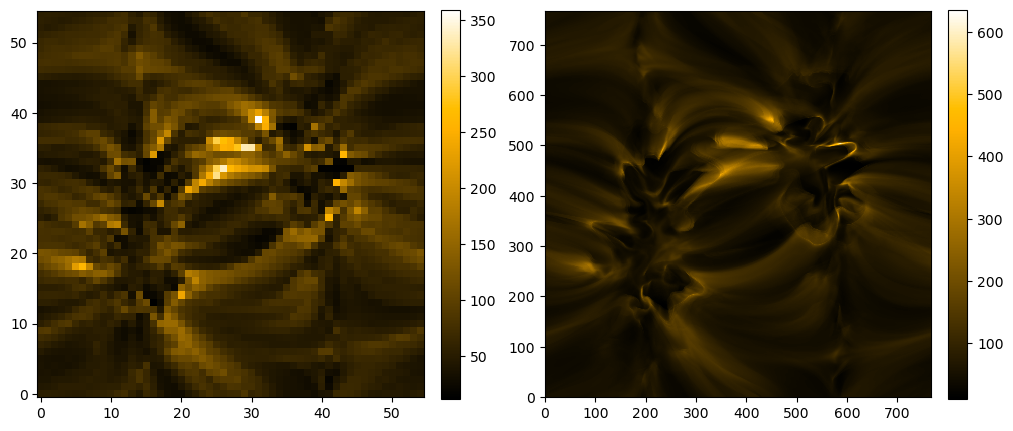

In [7]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12,6))
ax = ax.ravel()
im = ax[0].imshow(resampled,origin='lower', interpolation='none',cmap='sdoaia171')
plt.colorbar(im, ax=ax[0],fraction=0.046, pad=0.04)

im1 = ax[1].imshow(data_sim, origin='lower', interpolation='none',cmap='sdoaia171')
plt.colorbar(im1, ax=ax[1],fraction=0.046, pad=0.04)

In [9]:
resampled.shape, test_cut_out_map.data.shape

((55, 55), (58, 58))

## Computing filter-ratio maps for the resampled simulation and the observation


In [3]:
## QS VDEM synthesis
os.environ['VDEM_path'] = '/Users/souvikb/MUSE_outputs/vdems/'
vdem_file = os.path.join(os.environ['VDEM_path'], 'muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr')
qs_vdem = xr.open_zarr(vdem_file)
os.environ['RESPONSE'] = '/Users/souvikb/MUSE_outputs/response/new_response/'
work_dir = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/'
# date_sensitive = True
units = 'DN'
channels = [131,171,193,211] # for the Synthetic AIA channels
os.environ['aia_npz_data'] = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/'
str_prefix_npz = 'QS_AIA_'
aia_data_npz = sorted(glob.glob(os.environ['aia_npz_data'] + str_prefix_npz + '*.npz'))
ratio_over_time = [] #empty to store the ratio
synth_ratio_over_time =[]

for idx, file in tqdm(enumerate(sorted(aia_data_npz))):
    s = file
    stem = Path(s).stem # gives the filename without directory path and without the final extension
    m = re.search(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", stem) # scans stem for a datetime pattern like YYYY-MM-DDTHH:MM:SS
    dt_str = m.group(0) if m else None

    ## Begin the Response function and AIA synthesis section 
    date = Time(dt_str,format='isot',scale='utc') # astropy time object
    print(f' Date Sensitive AIA {units} Response from {date.strftime("%b %y")}')
    aia_resp = get_response(qs_vdem, date = date, save_response = True) # creating AIA response functions on the fly
    muse_AIA_QS = aia_synthesis(aia_resp, work_dir, vdem_file, swap_dims = False) # Synthesizing AIA QS data from VDEM
    
    # print(dt_str)
    path_to_cutouts = os.path.join(work_dir, f'SDO_EIS_cutouts_{dt_str}', 'bigger_sdo_cutouts')
    cutout_files = glob.glob(os.path.join(path_to_cutouts, '*.fits'))
    list_ratio = [] #empty to store the ratio
    synth_list_ratio = []
    for ii, f in enumerate(cutout_files):
        cutout = sunpy.map.Map(f)
        if cutout.wavelength.value != 6173 and cutout.wavelength.value != 335:
            if cutout.wavelength.value == 171:
                N_r = cutout.data/cutout.exposure_time.value
                synth_Nr = muse_AIA_QS.flux.sel(channel=171).squeeze().to_numpy()
                continue
            else:
                D_r = cutout.data/cutout.exposure_time.value
                synth_Dr = muse_AIA_QS.flux.sel(channel=int(cutout.wavelength.value)).squeeze().to_numpy()
            synth_list_ratio.append({
                'synth_ratio': synth_Nr/(synth_Dr+1e-2),
                'synth_ratio_name': f'171/{int(cutout.wavelength.value)}'

            })
            if N_r.shape == D_r.shape:
                ratio = N_r/(D_r+1e-2) # adding a small value to avoid division by zero
            else:
                H = min(N_r.shape[0], D_r.shape[0])
                W = min(N_r.shape[1], D_r.shape[1])
                ratio = N_r[:H, :W]/(D_r[:H, :W]+1e-2)
            list_ratio.append({
                'ratio': ratio,
                'ratio_name': f'171/{int(cutout.wavelength.value)}'
            })
        else:
            print(f"Skipping file {f} with wavelength {cutout.wavelength.value}")
    
    ratio_over_time.append({
    'date': dt_str,
    'ratios': list_ratio
    })
    synth_ratio_over_time.append({
    'date': dt_str,
    'synth_ratios': synth_list_ratio
    })




0it [00:00, ?it/s]

 Date Sensitive AIA DN Response from Apr 14
2026-04-03 23:23:02.507 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 0 months from obs_date 
2026-04-03 23:23:02.508 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Apr14.zarr already exists! Reading...
2026-04-03 23:23:02.632 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-04-03 23:23:02.632 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-04-03 23:23:02.632 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


1it [00:00,  2.17it/s]

Skipping file /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2014-04-28T13:22:00/bigger_sdo_cutouts/hmi.m_45s.20140428_140945_TAI.2.magnetogram.fits with wavelength 6173.0
Skipping file /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2014-04-28T13:22:00/bigger_sdo_cutouts/aia.lev1_euv_12s.2014-04-28T140916Z.335.image_lev1.fits with wavelength 335.0
 Date Sensitive AIA DN Response from Mar 16
2026-04-03 23:23:02.959 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 7 months from obs_date 
2026-04-03 23:23:02.959 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Aug15.zarr already exists! Reading...
2026-04-03 23:23:02.976 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-04-03 23:23:02.976 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_

2it [00:00,  2.68it/s]

...

Skipping file /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2016-03-22T00:18:40/bigger_sdo_cutouts/hmi.m_45s.20160322_002015_TAI.2.magnetogram.fits with wavelength 6173.0
Skipping file /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2016-03-22T00:18:40/bigger_sdo_cutouts/aia.lev1_euv_12s.2016-03-22T001939Z.335.image_lev1.fits with wavelength 335.0
 Date Sensitive AIA DN Response from Aug 19
2026-04-03 23:23:03.577 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 7 months from obs_date 
2026-04-03 23:23:03.578 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Jan19.zarr already exists! Reading...
2026-04-03 23:23:03.594 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-04-03 23:23:03.594 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_

4it [00:01,  3.07it/s]

Skipping file /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2019-08-17T04:33:00/bigger_sdo_cutouts/hmi.m_45s.20190817_043515_TAI.2.magnetogram.fits with wavelength 6173.0
Skipping file /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2019-08-17T04:33:00/bigger_sdo_cutouts/aia.lev1_euv_12s.2019-08-17T043438Z.335.image_lev1.fits with wavelength 335.0
 Date Sensitive AIA DN Response from Dec 19
2026-04-03 23:23:03.877 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 11 months from obs_date 
2026-04-03 23:23:03.877 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Jan19.zarr already exists! Reading...
2026-04-03 23:23:03.893 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-04-03 23:23:03.893 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS

5it [00:01,  2.90it/s]

Skipping file /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2019-12-01T16:24:00/bigger_sdo_cutouts/hmi.m_45s.20191201_162445_TAI.2.magnetogram.fits with wavelength 6173.0
Skipping file /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2019-12-01T16:24:00/bigger_sdo_cutouts/aia.lev1_euv_12s.2019-12-01T162414Z.335.image_lev1.fits with wavelength 335.0


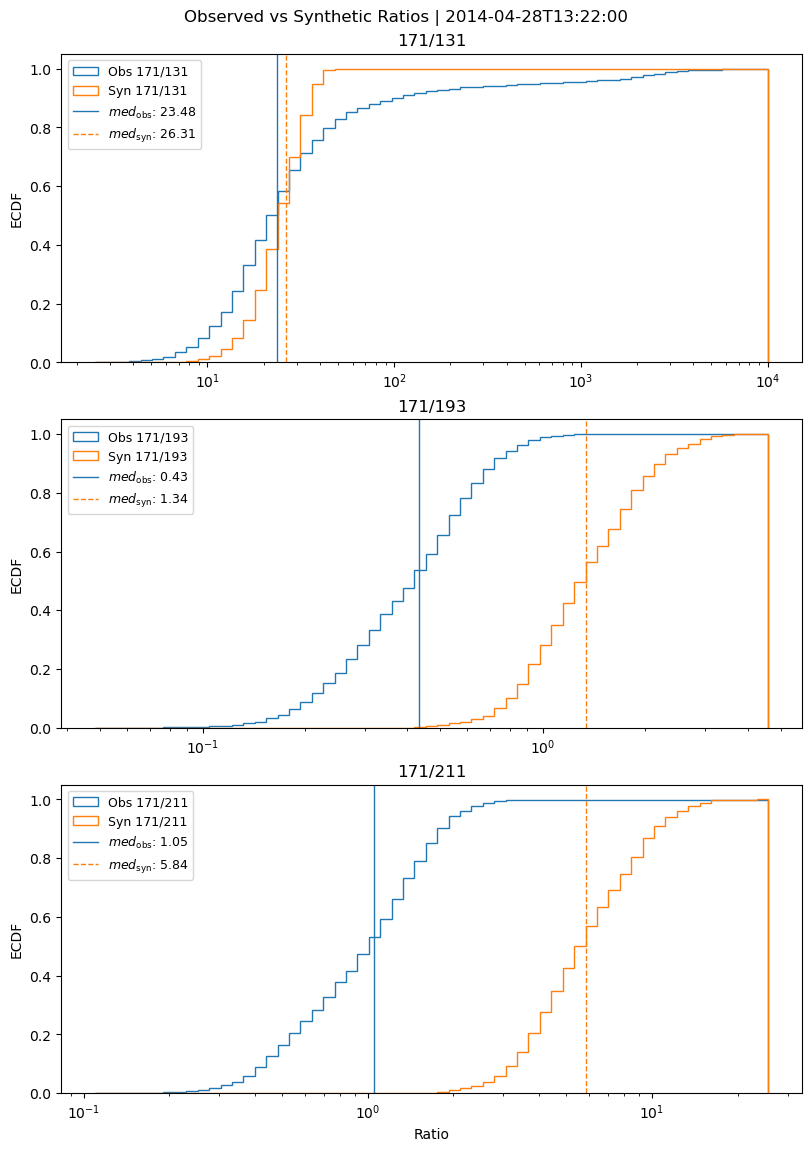

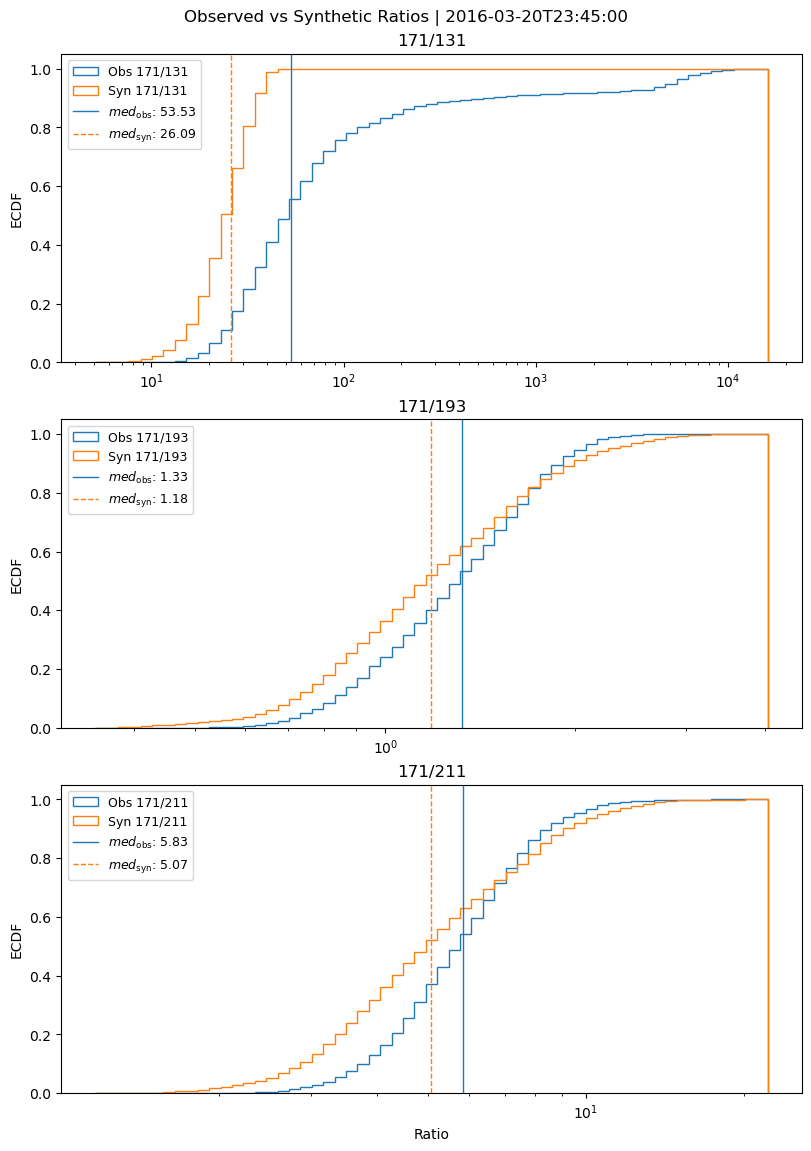

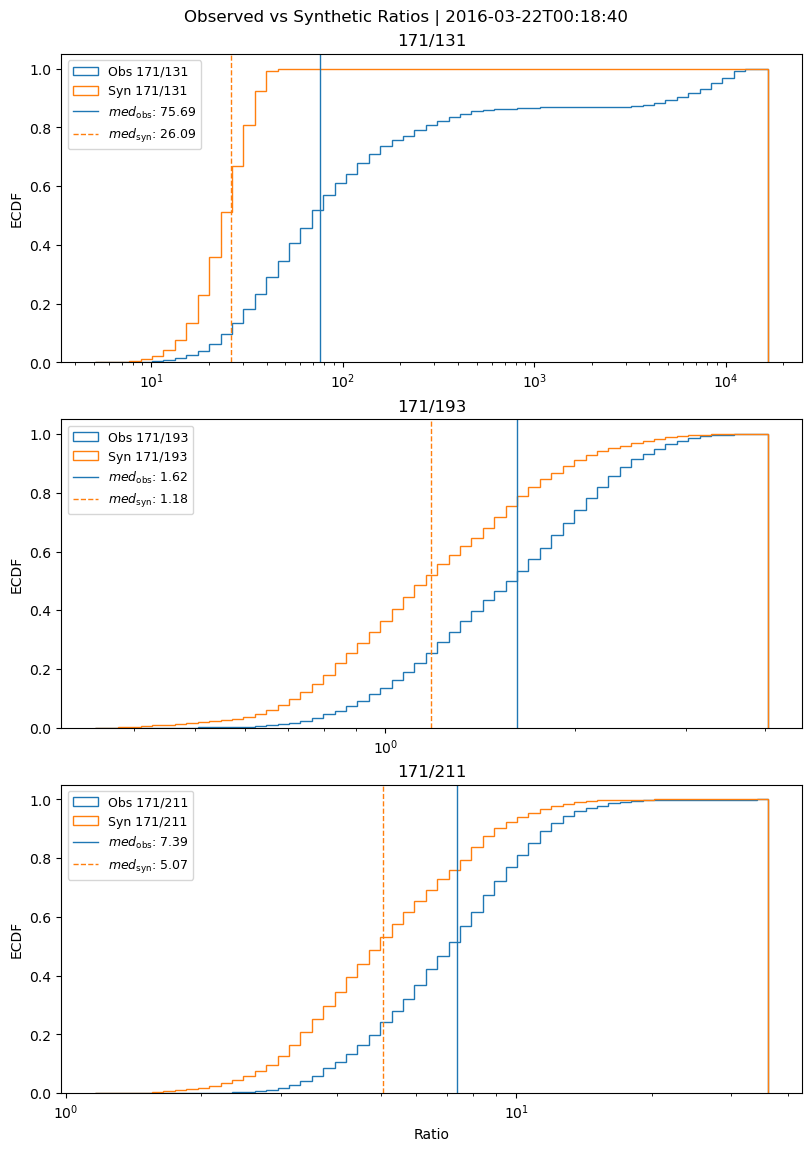

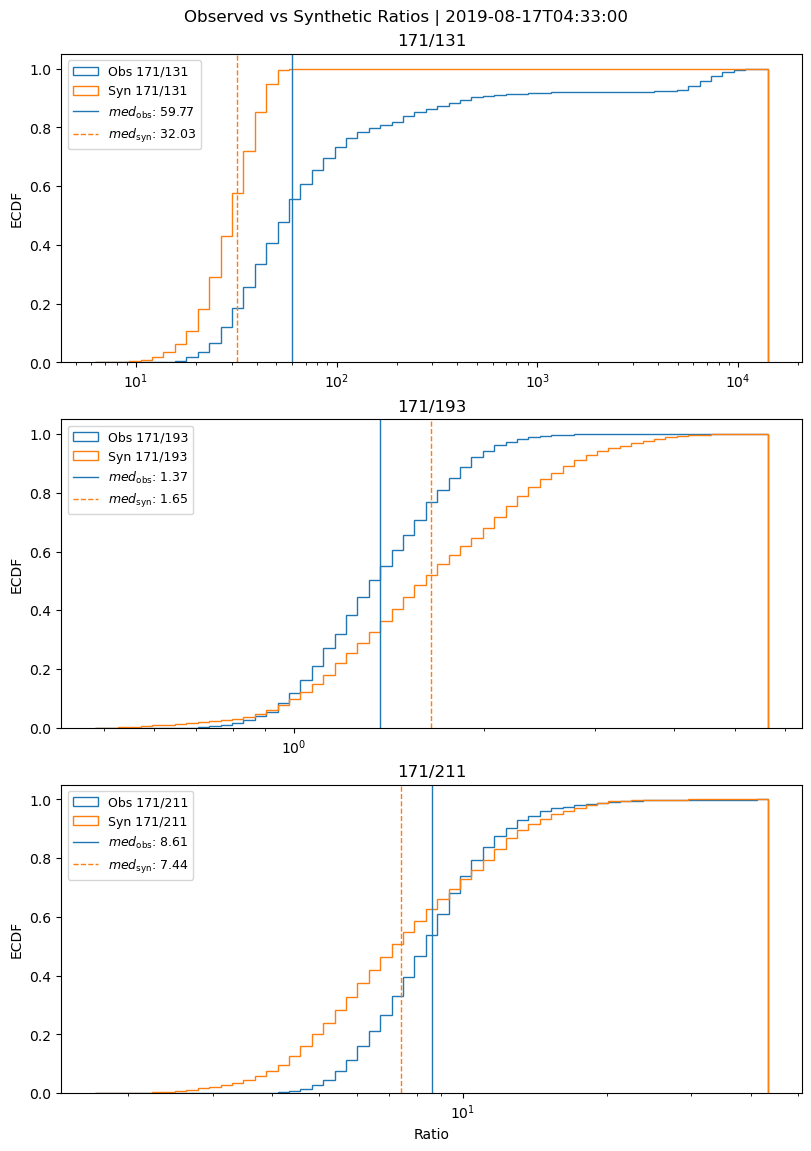

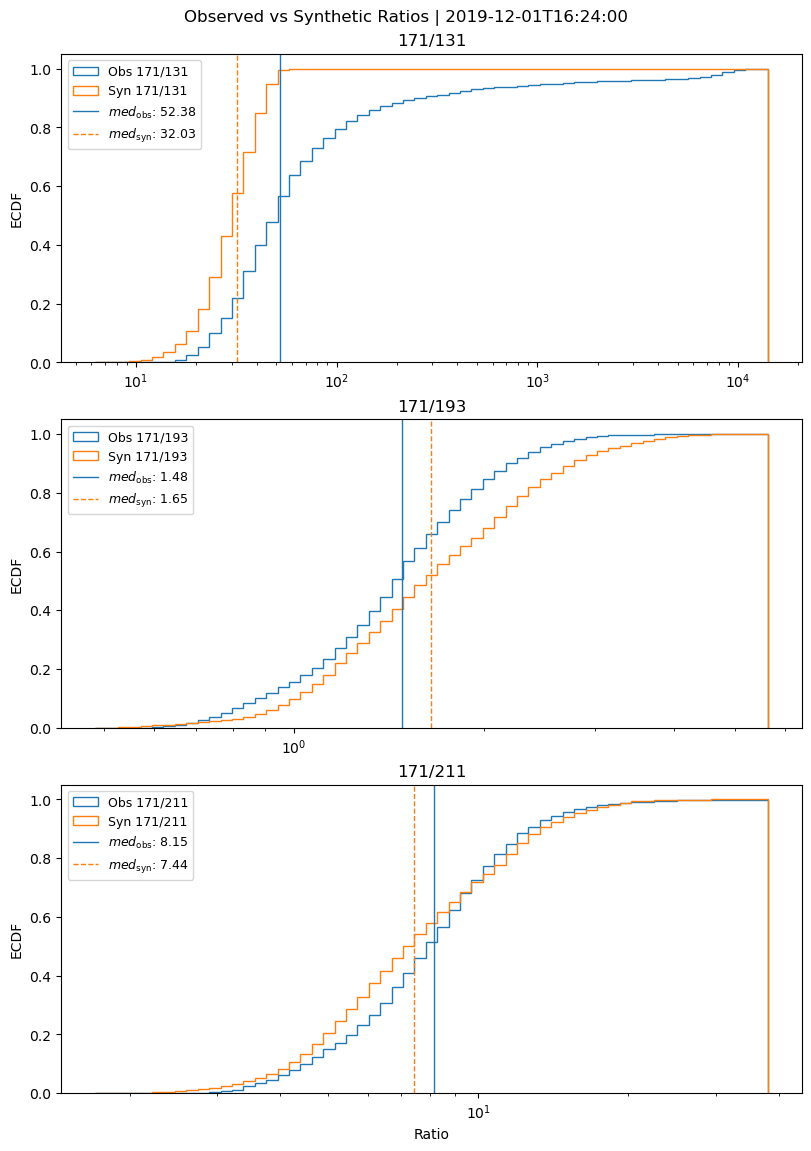

In [4]:
num_bins = 60

# Build date lookup from metadata
obs_by_date = {d["date"]: d for d in ratio_over_time}
syn_by_date = {d["date"]: d for d in synth_ratio_over_time}
common_dates = sorted(set(obs_by_date).intersection(syn_by_date))

for date in common_dates:
    obs_entry = obs_by_date[date]
    syn_entry = syn_by_date[date]

    # Use ratio names from metadata (no hardcoding)
    obs_map = {r["ratio_name"]: r["ratio"] for r in obs_entry["ratios"]}
    syn_map = {r["synth_ratio_name"]: r["synth_ratio"] for r in syn_entry["synth_ratios"]}
    ratio_names = sorted(set(obs_map).intersection(syn_map))  # e.g. 171/131, 171/193, 171/211

    fig, axes = plt.subplots(len(ratio_names), 1, figsize=(8, 3.8 * len(ratio_names)), constrained_layout=True)
    if len(ratio_names) == 1:
        axes = [axes]

    fig.suptitle(f"Observed vs Synthetic Ratios | {date}", fontsize=12)

    for ax, rn in zip(axes, ratio_names):
        obs = np.ravel(obs_map[rn]).astype(float)
        syn = np.ravel(syn_map[rn]).astype(float)

        obs = obs[np.isfinite(obs) & (obs > 0)]
        syn = syn[np.isfinite(syn) & (syn > 0)]

        if len(obs) == 0 or len(syn) == 0:
            ax.text(0.5, 0.5, f"No valid data for {rn}", ha="center", va="center")
            ax.set_axis_off()
            continue

        # Shared bins from combined obs+syn (handles different image sizes safely)
        combined = np.concatenate([obs, syn])
        min_val = max(combined.min(), 1e-6)
        max_val = combined.max()
        bins = np.logspace(np.log10(min_val), np.log10(max_val), num_bins)

        ax.hist(obs, bins=bins, cumulative=True, histtype="step",
                weights=np.ones(len(obs))/len(obs), color="tab:blue", lw=2,
                label=f"Obs {rn}")
        ax.hist(syn, bins=bins, cumulative=True, histtype="step",
                weights=np.ones(len(syn))/len(syn), color="tab:orange", lw=2, ls="--",
                label=f"Syn {rn}")

        ax.axvline(np.median(obs), color="tab:blue", lw=1, ls="-",
                   label=f'$med_{{\mathrm{{obs}}}}$: {np.median(obs):.2f}')
        ax.axvline(np.median(syn), color="tab:orange", lw=1, ls="--",
                   label=f'$med_{{\mathrm{{syn}}}}$: {np.median(syn):.2f}')
        # print(date, rn,
        #       "obs q50/q95/q99:", np.quantile(obs, [0.5, 0.95, 0.99]),
        #       "syn q50/q95/q99:", np.quantile(syn, [0.5, 0.95, 0.99]))

        ax.set_xscale("log")
        ax.set_ylabel("ECDF")
        ax.set_title(rn)
        # ax.grid(alpha=0.3)
        ax.legend(fontsize=9)

    axes[-1].set_xlabel("Ratio")
    plt.show()


## Plotting observed vs synthetic intensities as a function of time


0it [00:00, ?it/s]

 Date Sensitive AIA DN Response from Apr 14
2026-04-03 23:23:40.932 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 0 months from obs_date 
2026-04-03 23:23:40.933 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Apr14.zarr already exists! Reading...
2026-04-03 23:23:40.956 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-04-03 23:23:40.956 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-04-03 23:23:40.956 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


1it [00:00,  1.76it/s]

 Date Sensitive AIA DN Response from Mar 16
2026-04-03 23:23:41.500 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 7 months from obs_date 
2026-04-03 23:23:41.500 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Aug15.zarr already exists! Reading...
2026-04-03 23:23:41.516 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-04-03 23:23:41.517 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-04-03 23:23:41.517 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


2it [00:01,  1.69it/s]

...

3it [00:01,  1.78it/s]

 Date Sensitive AIA DN Response from Aug 19
2026-04-03 23:23:42.635 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 7 months from obs_date 
2026-04-03 23:23:42.636 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Jan19.zarr already exists! Reading...
2026-04-03 23:23:42.652 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-04-03 23:23:42.652 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-04-03 23:23:42.652 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


4it [00:02,  1.78it/s]

 Date Sensitive AIA DN Response from Dec 19
2026-04-03 23:23:43.196 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 11 months from obs_date 
2026-04-03 23:23:43.196 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Jan19.zarr already exists! Reading...
2026-04-03 23:23:43.213 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-04-03 23:23:43.214 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-04-03 23:23:43.214 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


5it [00:02,  1.71it/s]


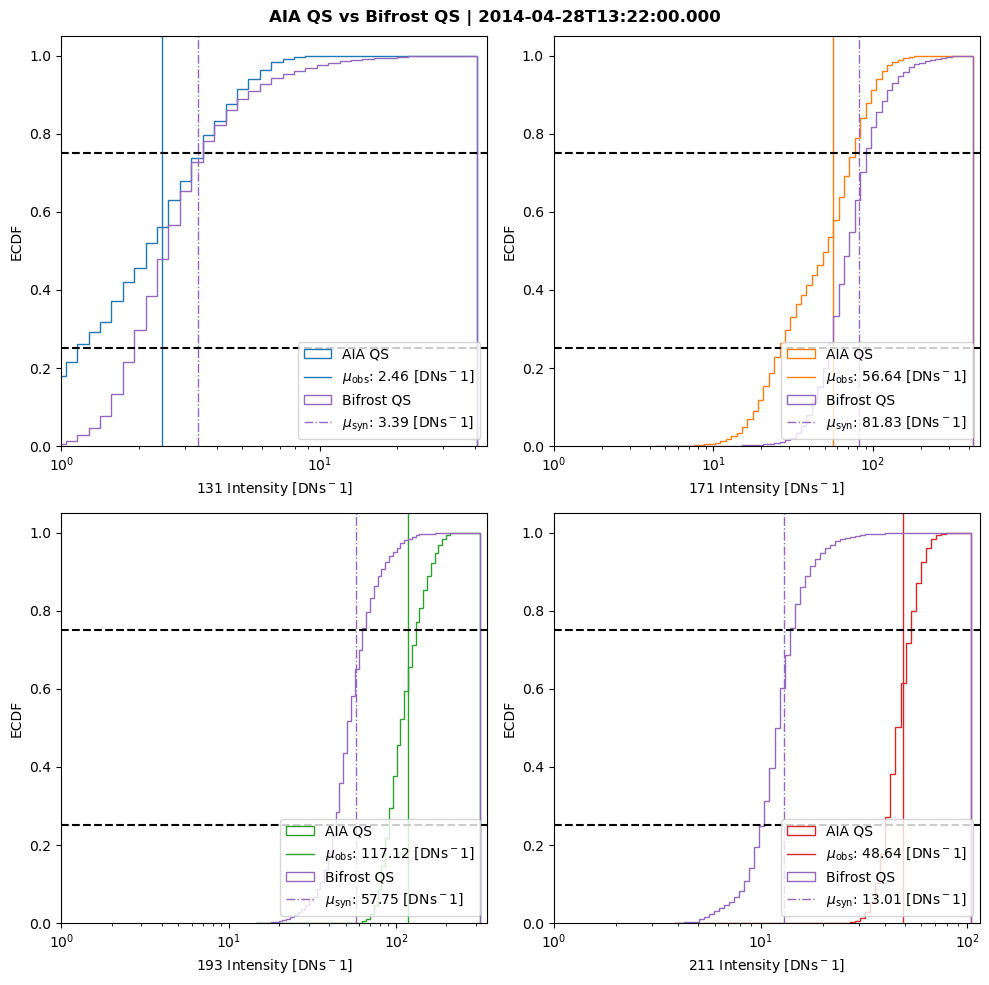

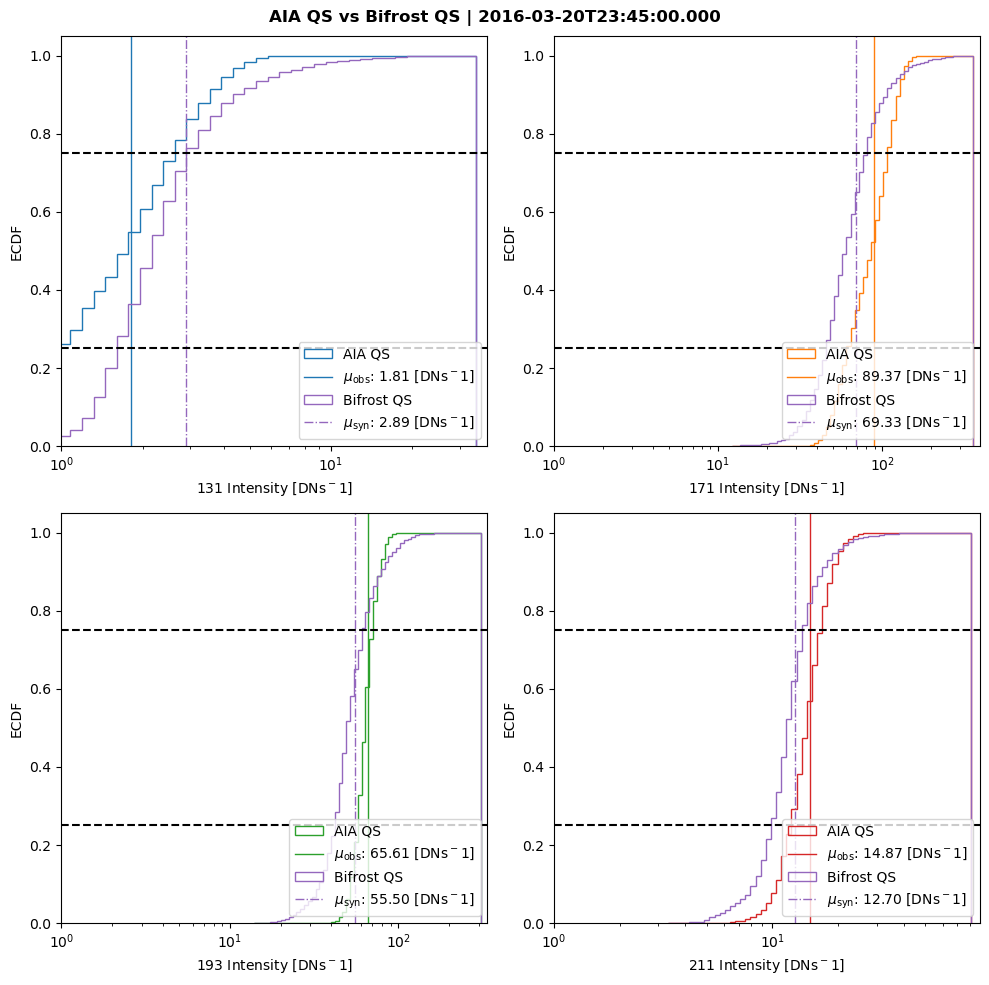

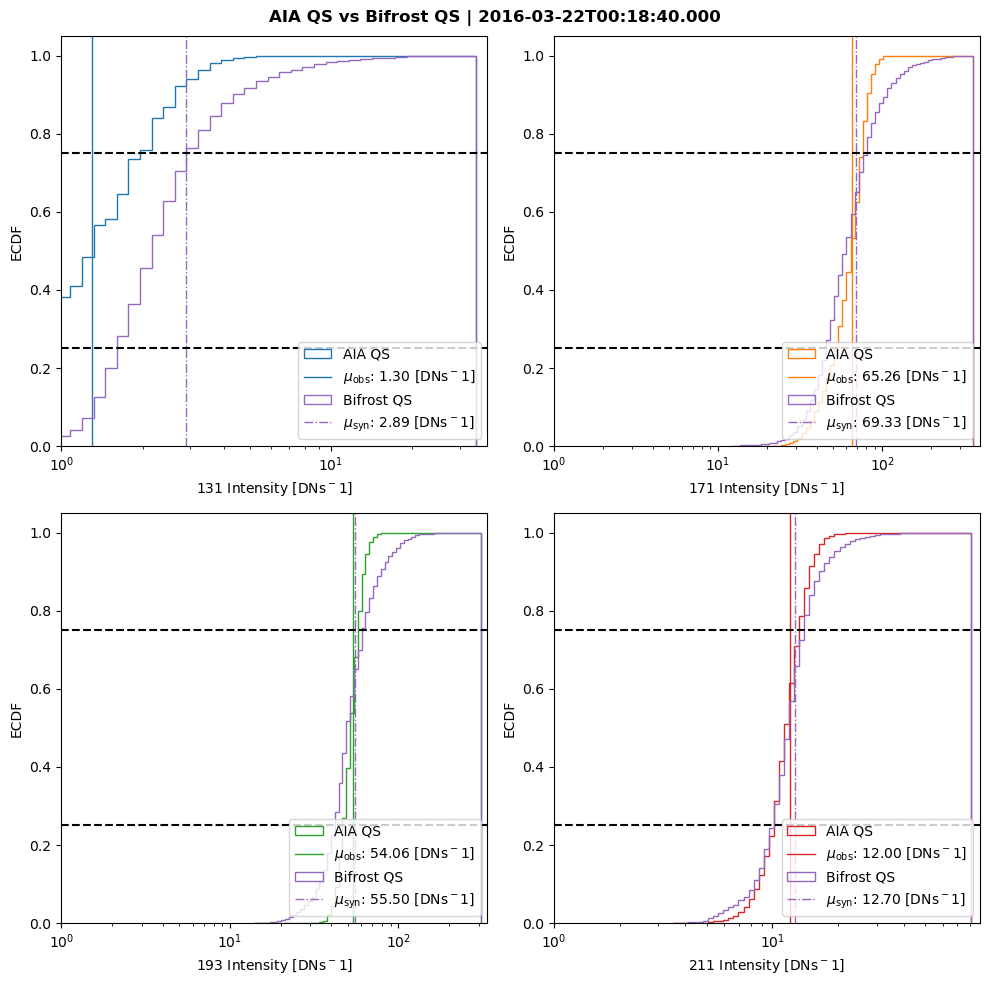

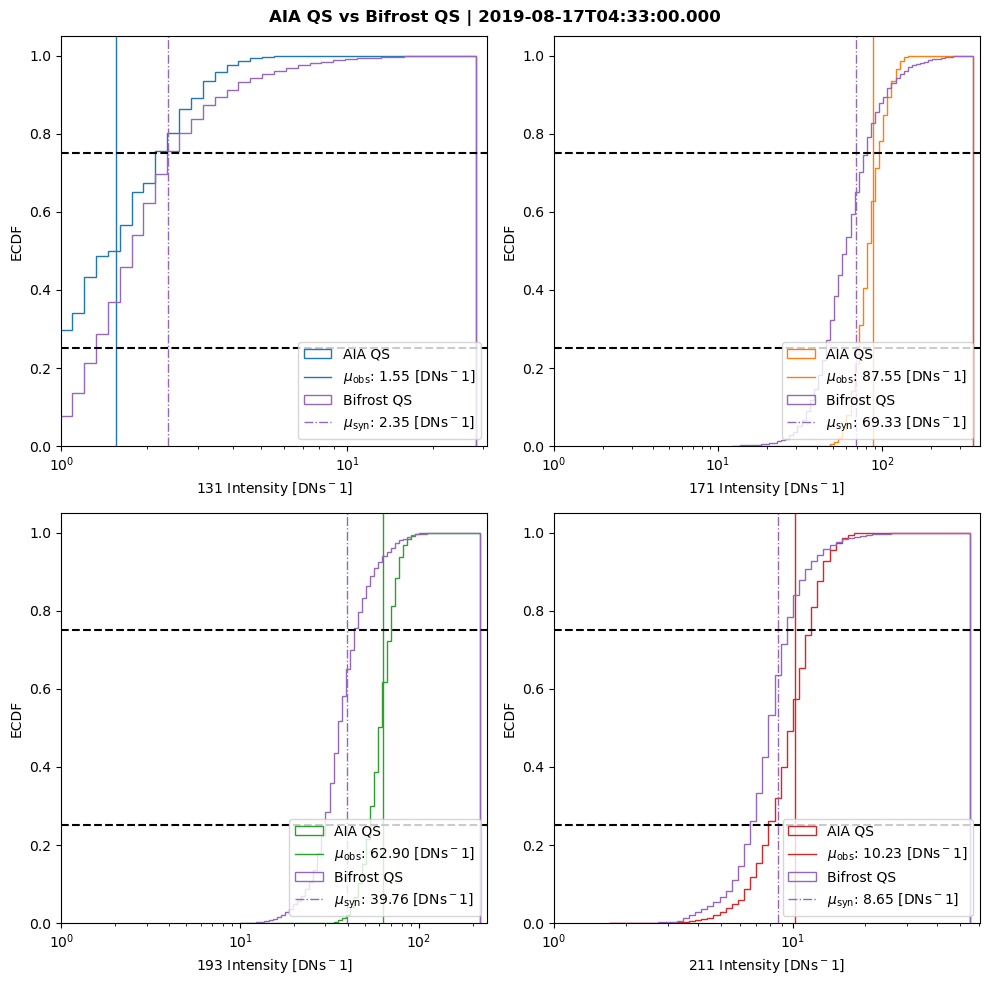

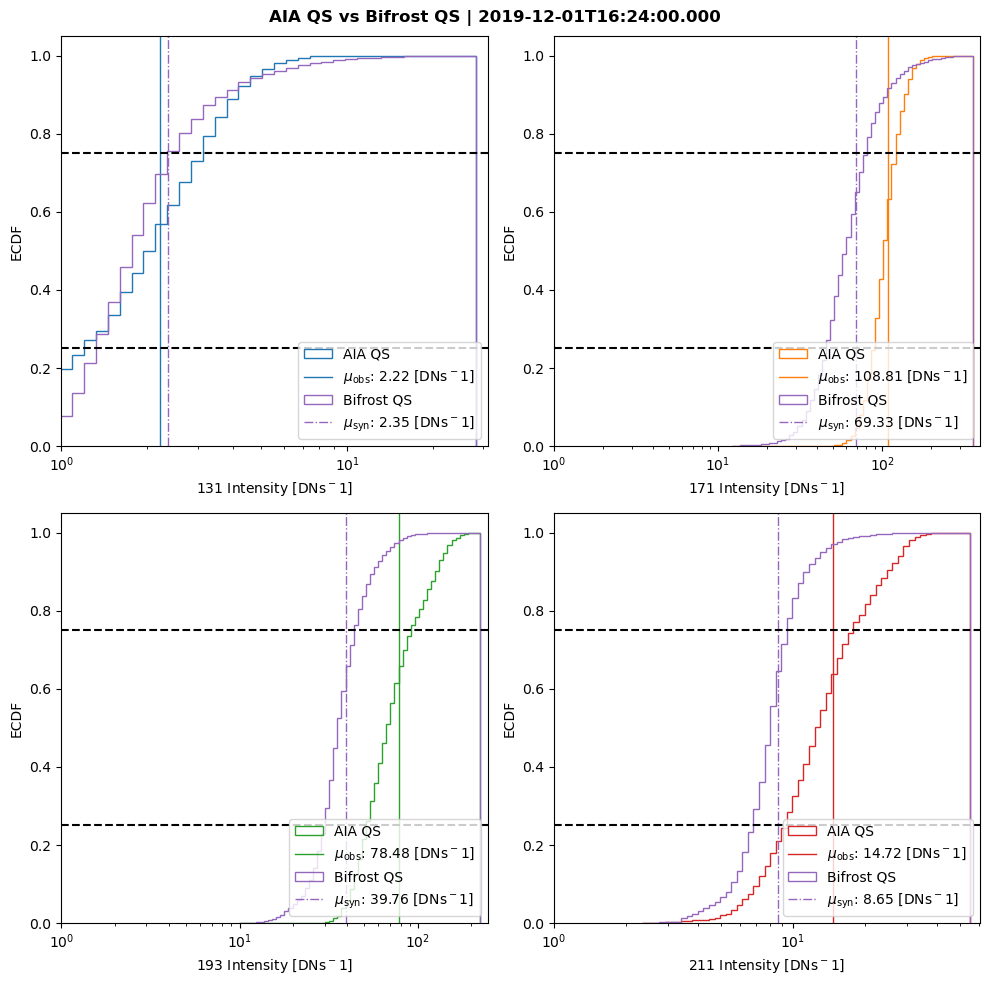

In [5]:
## QS VDEM synthesis
region = 'QS'
MHD_code ='Bifrost'
snapname = 'QS'
os.environ['VDEM_path'] = '/Users/souvikb/MUSE_outputs/vdems/'
colors_channel = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
vdem_file = os.path.join(os.environ['VDEM_path'], 'muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr')
qs_vdem = xr.open_zarr(vdem_file)
os.environ['RESPONSE'] = '/Users/souvikb/MUSE_outputs/response/new_response/'
work_dir = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/'
# date_sensitive = True
units = 'DN'
channels = np.array([131,171,193,211]) # for the Synthetic AIA channels
os.environ['aia_npz_data'] = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/'
str_prefix_npz = 'QS_AIA_'
aia_data_npz = sorted(glob.glob(os.environ['aia_npz_data'] + str_prefix_npz + '*.npz'))

for idx, file in tqdm(enumerate(sorted(aia_data_npz))):
    s = file
    stem = Path(s).stem # gives the filename without directory path and without the final extension
    m = re.search(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", stem) # scans stem for a datetime pattern like YYYY-MM-DDTHH:MM:SS
    dt_str = m.group(0) if m else None

    ## Begin the Response function and AIA synthesis section 
    date = Time(dt_str,format='isot',scale='utc') # astropy time object
    print(f' Date Sensitive AIA {units} Response from {date.strftime("%b %y")}')
    aia_resp = get_response(qs_vdem, date = date, save_response = True) # creating AIA response functions on the fly
    muse_AIA_QS = aia_synthesis(aia_resp, work_dir, vdem_file, swap_dims = False) # Synthesizing AIA QS data from VDEM
    
    # print(dt_str)
    path_to_cutouts = os.path.join(work_dir, f'SDO_EIS_cutouts_{dt_str}', 'bigger_sdo_cutouts')
    cutout_files = glob.glob(os.path.join(path_to_cutouts, '*.fits'))

    fig, ax = plt.subplots(2,2,figsize=(10,10))
    fig.suptitle(f"AIA QS vs Bifrost QS | {date}", fontsize=12,y=0.98, fontweight='bold')
    i = 0 #for the subplot indexing
    for kk, f in enumerate(cutout_files):
        cutout = sunpy.map.Map(f)
        if cutout.wavelength.value != 6173 and cutout.wavelength.value != 335:
            # i += 1
            i=np.argwhere(channels == cutout.wavelength.value).flatten()[0] # for making sure the correct channel goes to the correct subplot
            data_sim = muse_AIA_QS.flux.sel(channel=int(cutout.wavelength.value)).squeeze().data
            scale_sim = (muse_AIA_QS.flux.y[1]-muse_AIA_QS.flux.y[0])*1e-2*1e-3 #pixel scale in km for the synth AIA data
            aia_scale_x = cutout.scale[0].value*722 #km
            aia_scale_y = cutout.scale[1].value*722 #km
            # print('\n Preforming resampling for wavelength', cutout.wavelength.value)
            resampled= zoom(data_sim,
                            zoom=(scale_sim.item()/aia_scale_x, scale_sim.item()/aia_scale_y),
                            order=3, #order = 3 Cubic spline interpolation
                            mode='nearest') # for edges
            obs_data = np.ravel(cutout.data/cutout.exposure_time.value).astype(float)
            synth_data = np.ravel(resampled).astype(float)
            combined = np.concatenate([obs_data, synth_data])
            min_val = max(combined.min(), 1e-1)
            obs_plot = obs_data[np.isfinite(obs_data) & (obs_data >= min_val)]
            syn_plot = synth_data[np.isfinite(synth_data) & (synth_data >= min_val)]

            max_val = combined.max()
            bins_new = np.logspace(np.log10(min_val), np.log10(max_val), 60)
            hist, bin_edges = np.histogram(obs_data, bins=bins_new)
            ax[i//2][i%2].hist(obs_plot, bins=bins_new, label=f'AIA {region}',cumulative=True, histtype='step',
                                weights=np.ones(len(obs_plot)) / len(obs_plot), color=colors_channel[i], lw=2.)
            ax[i//2][i%2].axvline(x=np.mean(obs_data),color=colors_channel[i],lw=1,ls='-',
                                    label=f'$\mu_{{\mathrm{{obs}}}}$: {np.mean(obs_data):.2f} [DNs$^{-1}$]')

            ax[i//2][i%2].hist(syn_plot, bins=bins_new, label=f'{MHD_code} {snapname}',cumulative=True, histtype='step',
                                weights=np.ones(len(syn_plot)) / len(syn_plot),color='tab:purple',ls='-.',lw=2.)
            ax[i//2][i%2].axvline(x=np.mean(synth_data),color='tab:purple',lw=1,ls='-.',label=f'$\mu_{{\mathrm{{syn}}}}$: {np.mean(synth_data):.2f} [DNs$^{-1}$]')
            ax[i//2][i%2].set_xlabel(fr'{int(cutout.wavelength.value)} Intensity [DNs$^{-1}$]')
            ax[i//2][i%2].set_xlim([1, max_val * 1.1])
            ax[i//2][i%2].set_xscale('log')
            ax[i//2][i%2].set_ylabel('ECDF')
            ax[i//2][i%2].legend(loc='lower right')
            ax[i//2][i%2].axhline(y=0.25,color='black',ls='--')
            ax[i//2][i%2].axhline(y=0.75,color='black',ls='--')
        plt.tight_layout()




## plotting the SDO cutouts 

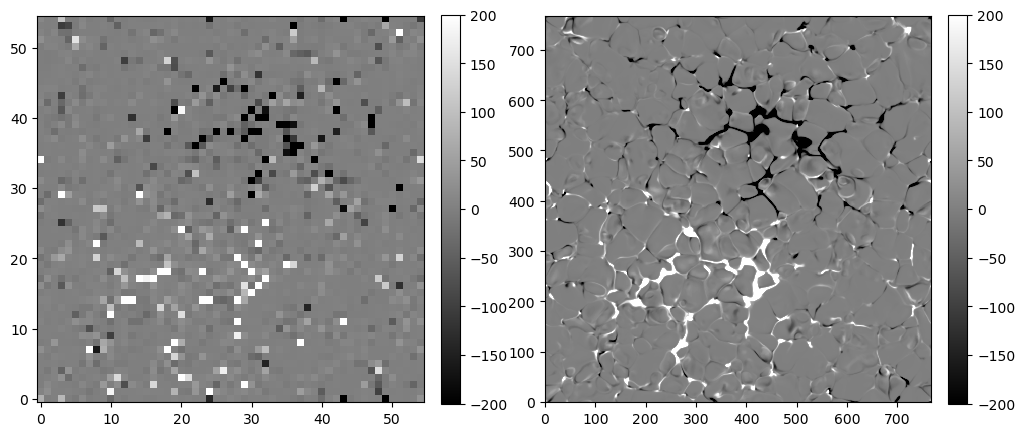

In [6]:
path_sim_mag = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/Bifrost/'
mag = np.load(path_sim_mag+'Bz_z=0.15_010.npy')
# data_sim = muse_AIA_QS.flux.sel(channel=171).squeeze().data
aia_scale_x = test_cut_out_map.scale[0].value*722 #km
aia_scale_y = test_cut_out_map.scale[1].value*722 #km
resampled_mag= zoom(mag,
                zoom=(scale_sim.item()/aia_scale_x, scale_sim.item()/aia_scale_y),
                order=3, #order = 3 Cubic spline interpolation
                mode='nearest') # for edges

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12,6))
ax = ax.ravel()
im = ax[0].imshow(resampled_mag,origin='lower', interpolation='none',cmap='gray',vmax=200,vmin=-200)
plt.colorbar(im, ax=ax[0],fraction=0.046, pad=0.04)

im1 = ax[1].imshow(mag, origin='lower', interpolation='none',cmap='gray',vmax=200,vmin=-200)
plt.colorbar(im1, ax=ax[1],fraction=0.046, pad=0.04)

0it [00:00, ?it/s]

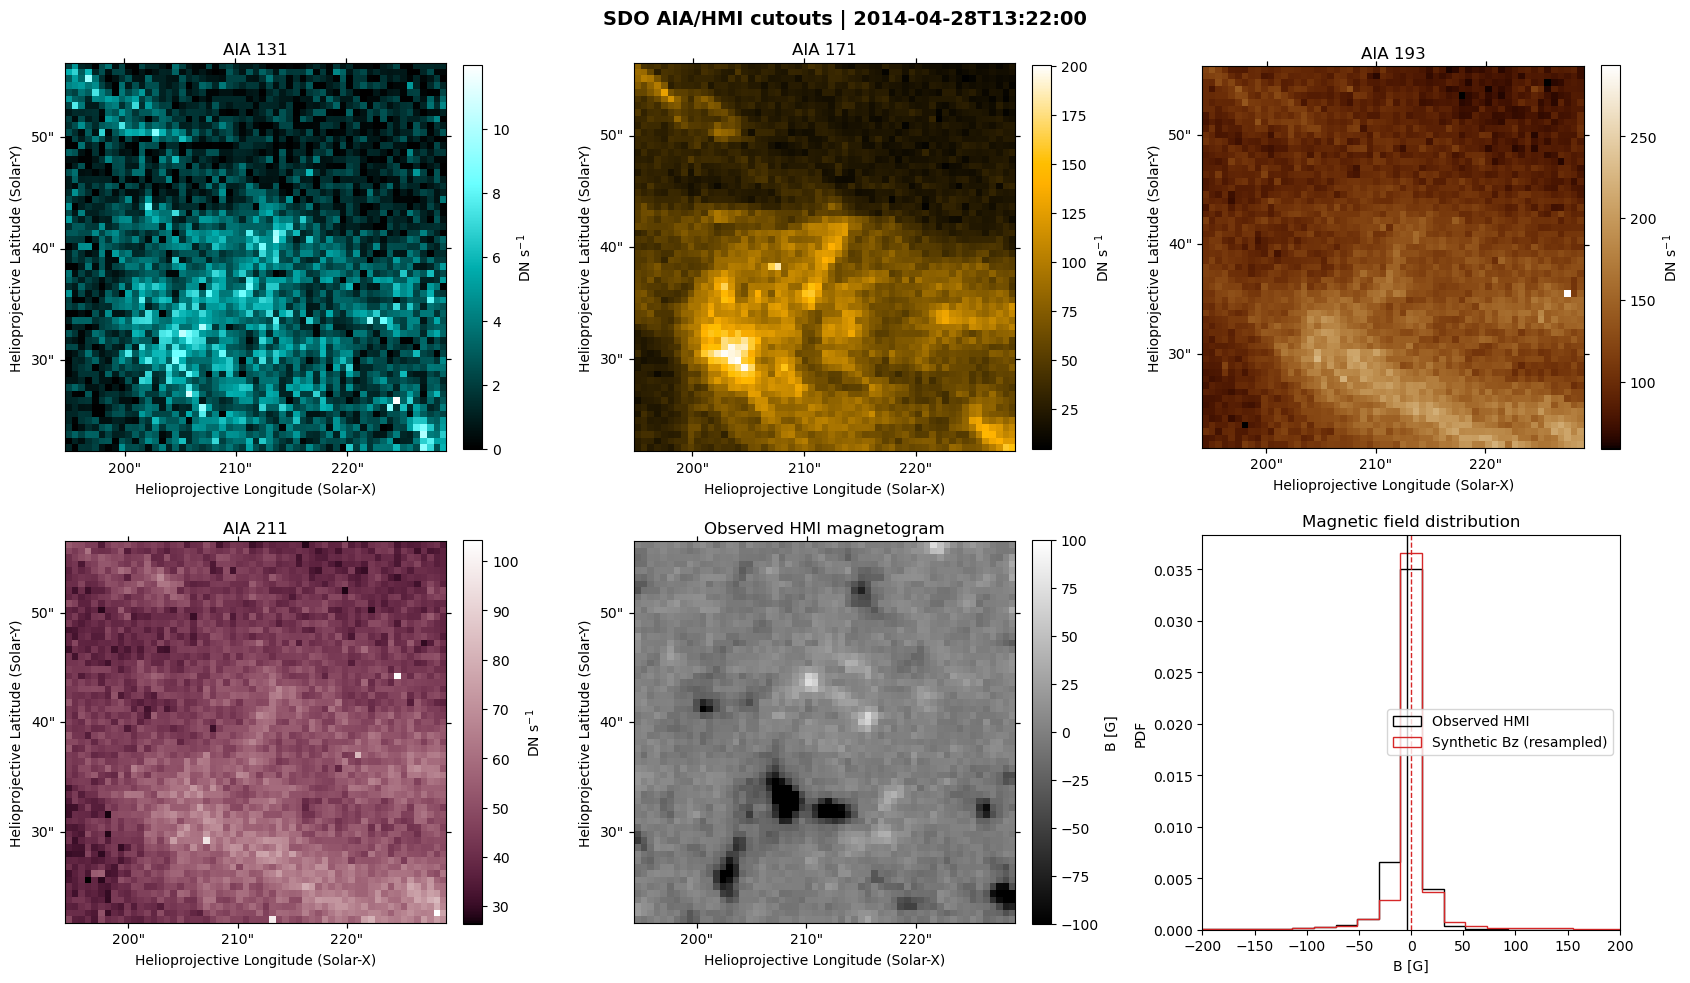

1it [00:01,  1.09s/it]

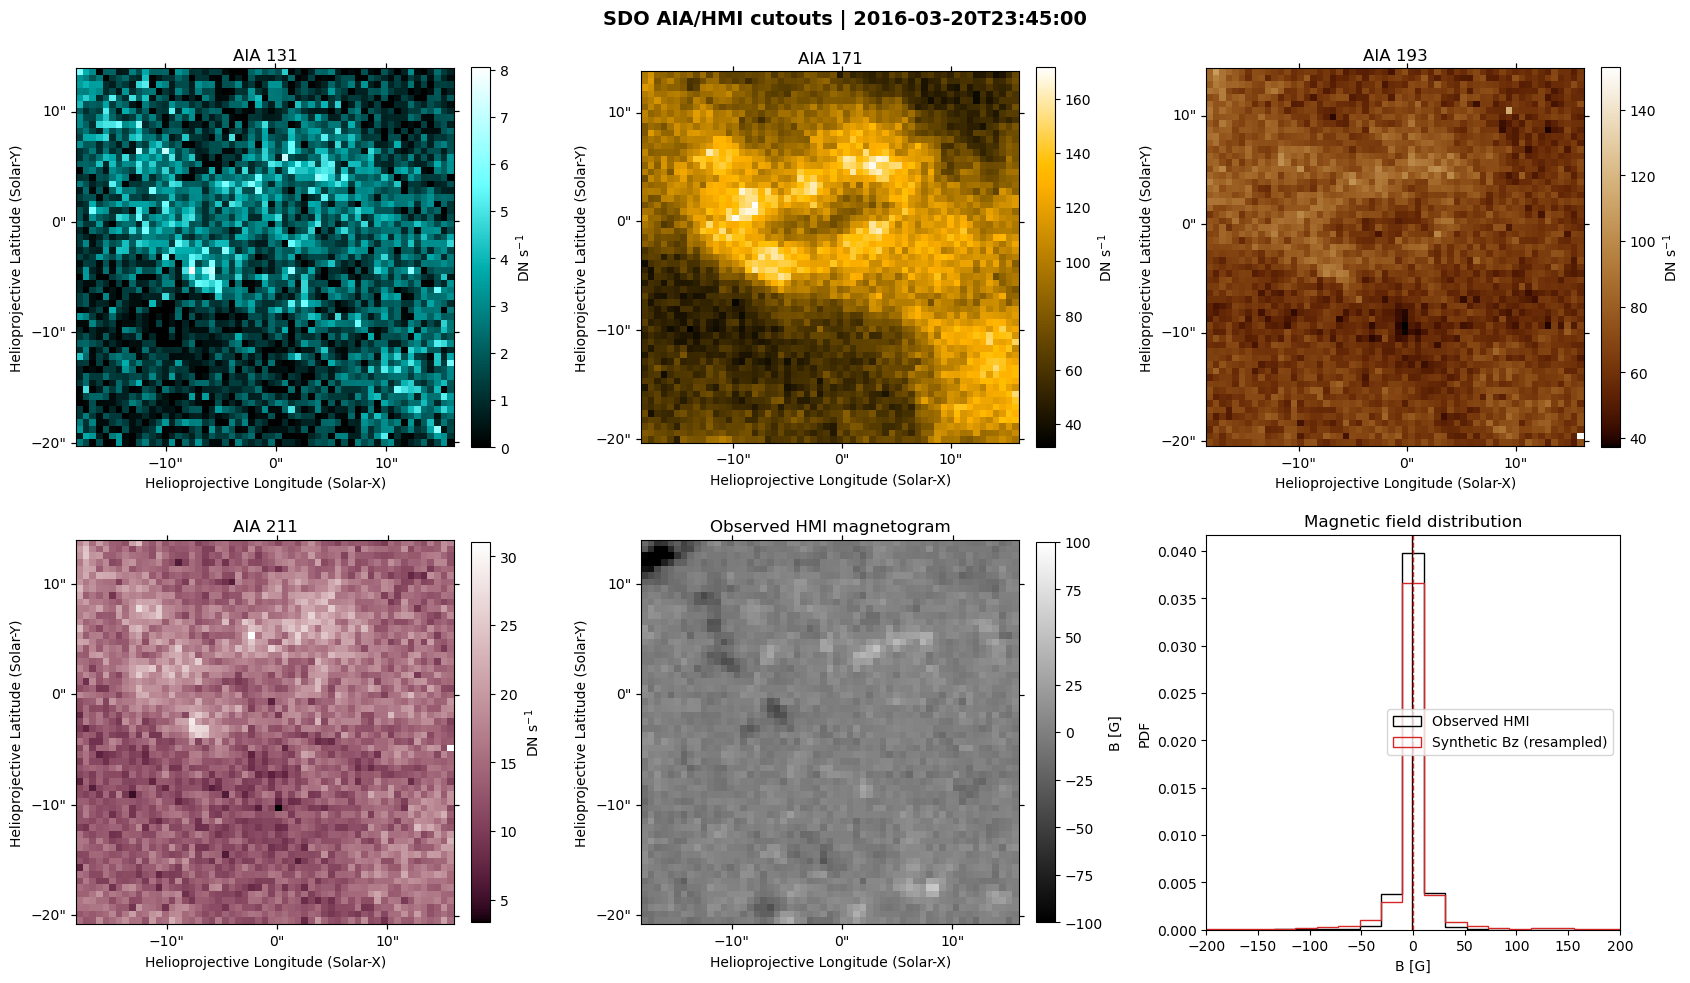

2it [00:02,  1.15s/it]

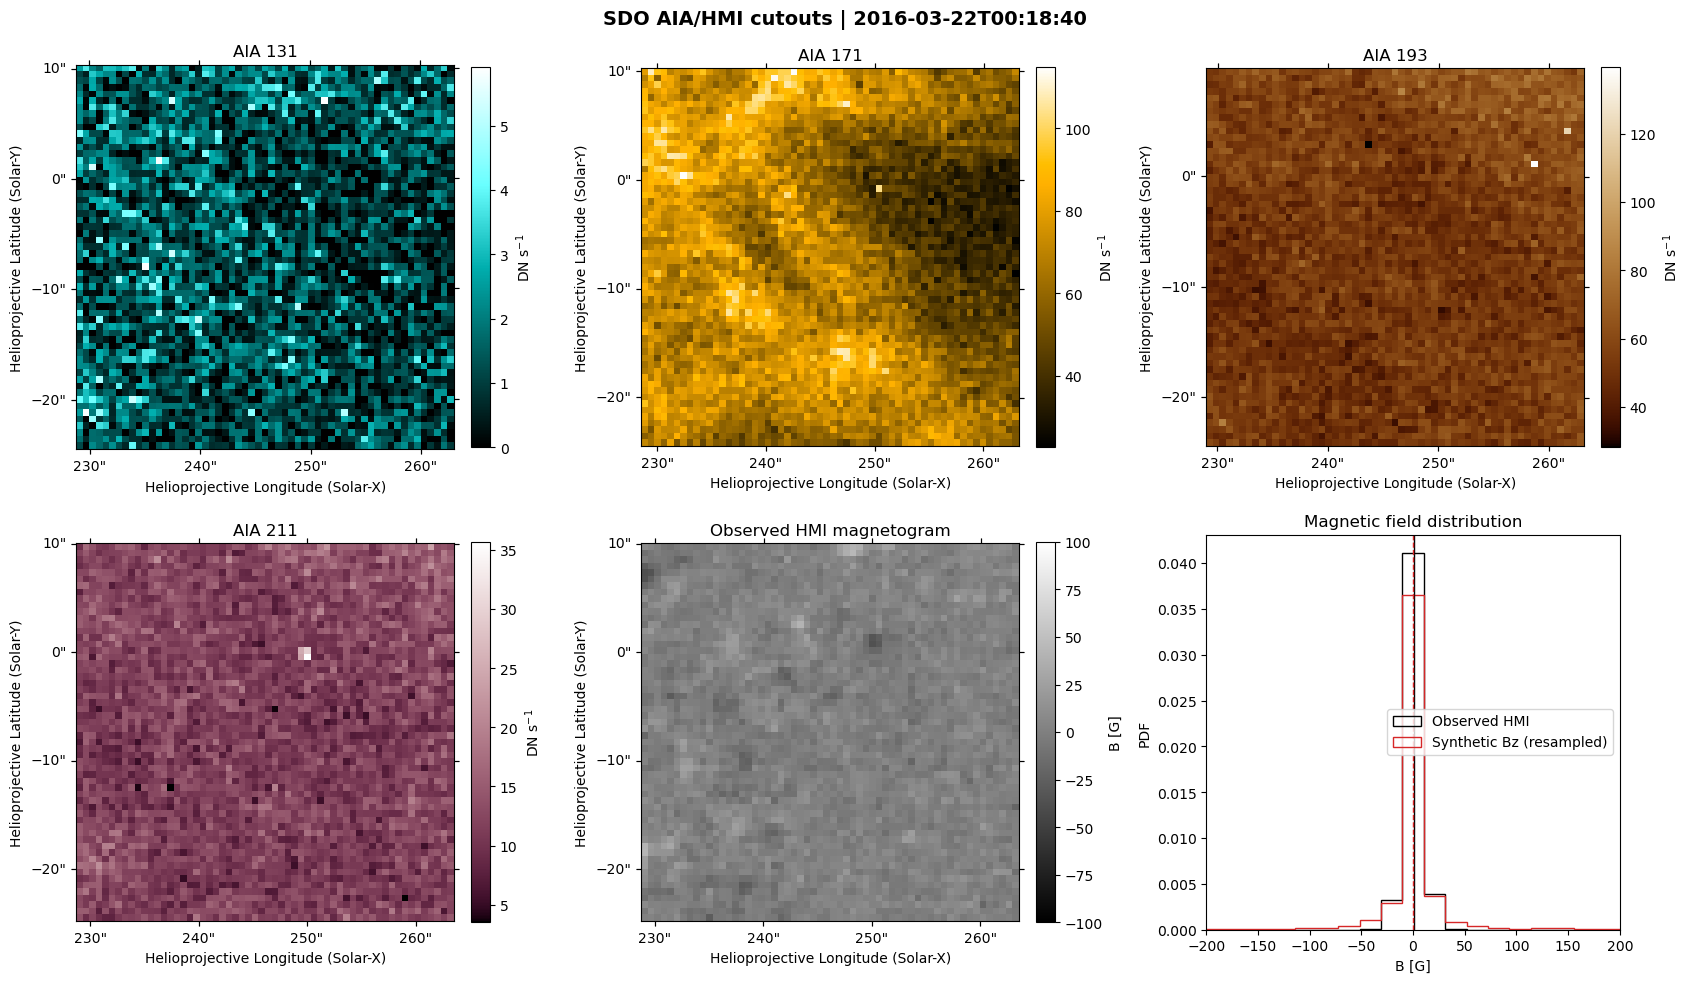

3it [00:03,  1.12s/it]

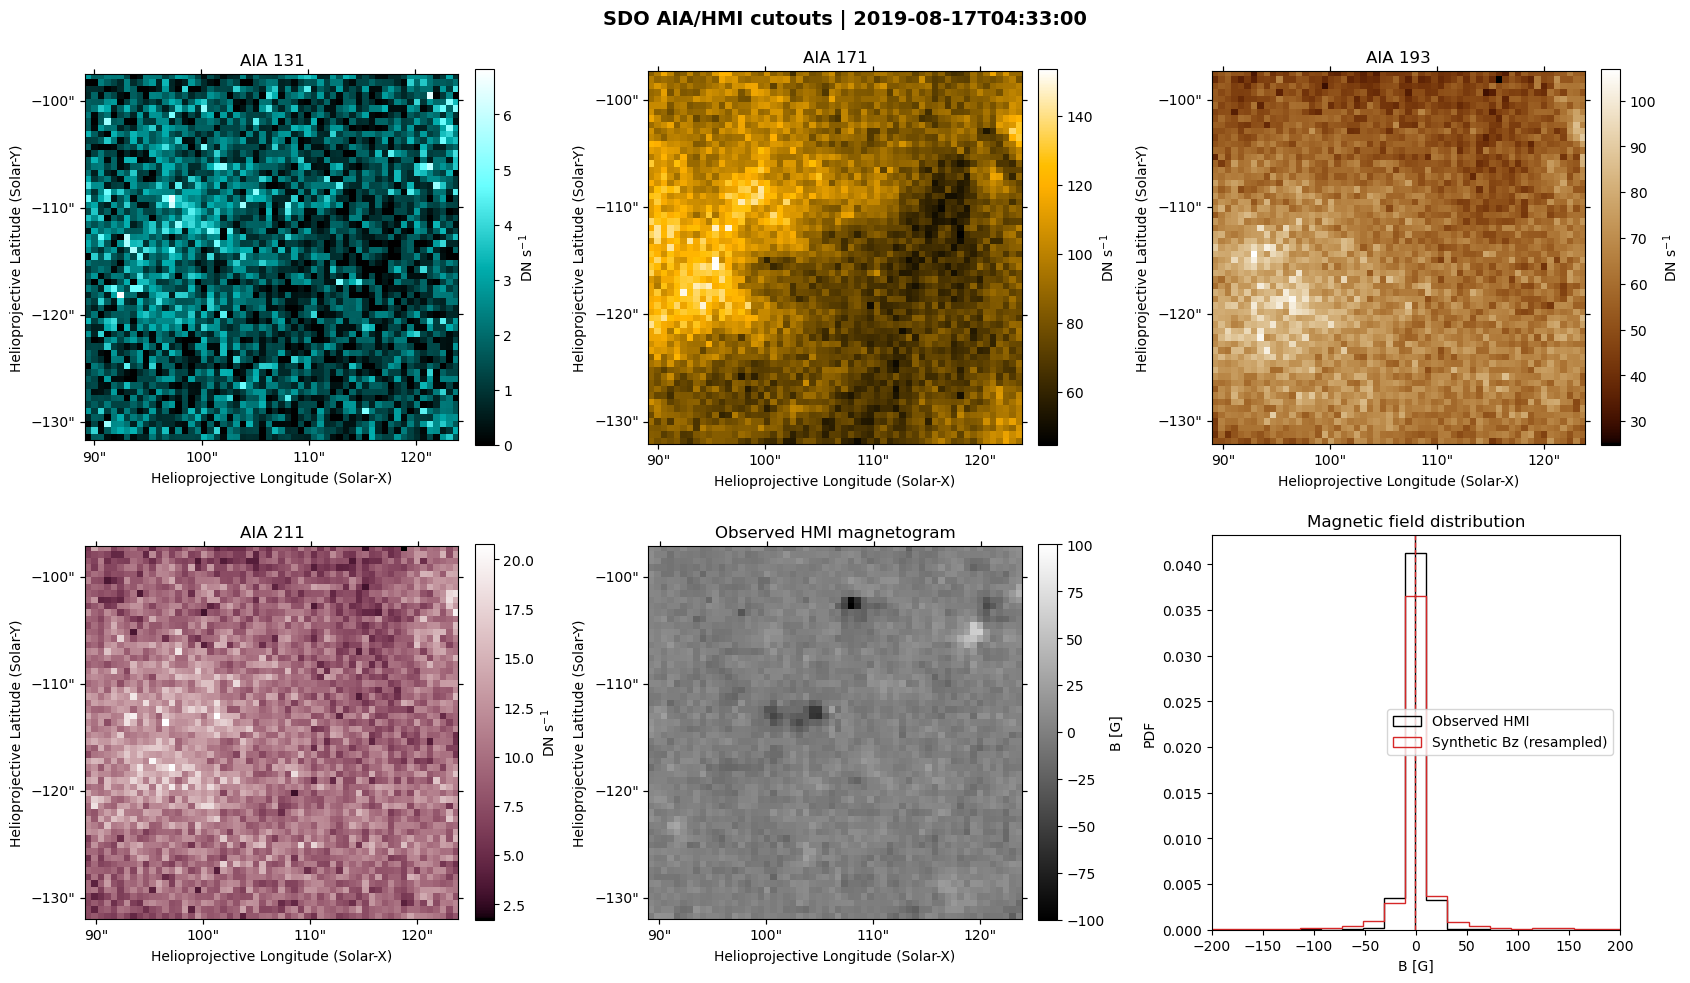

4it [00:04,  1.10s/it]

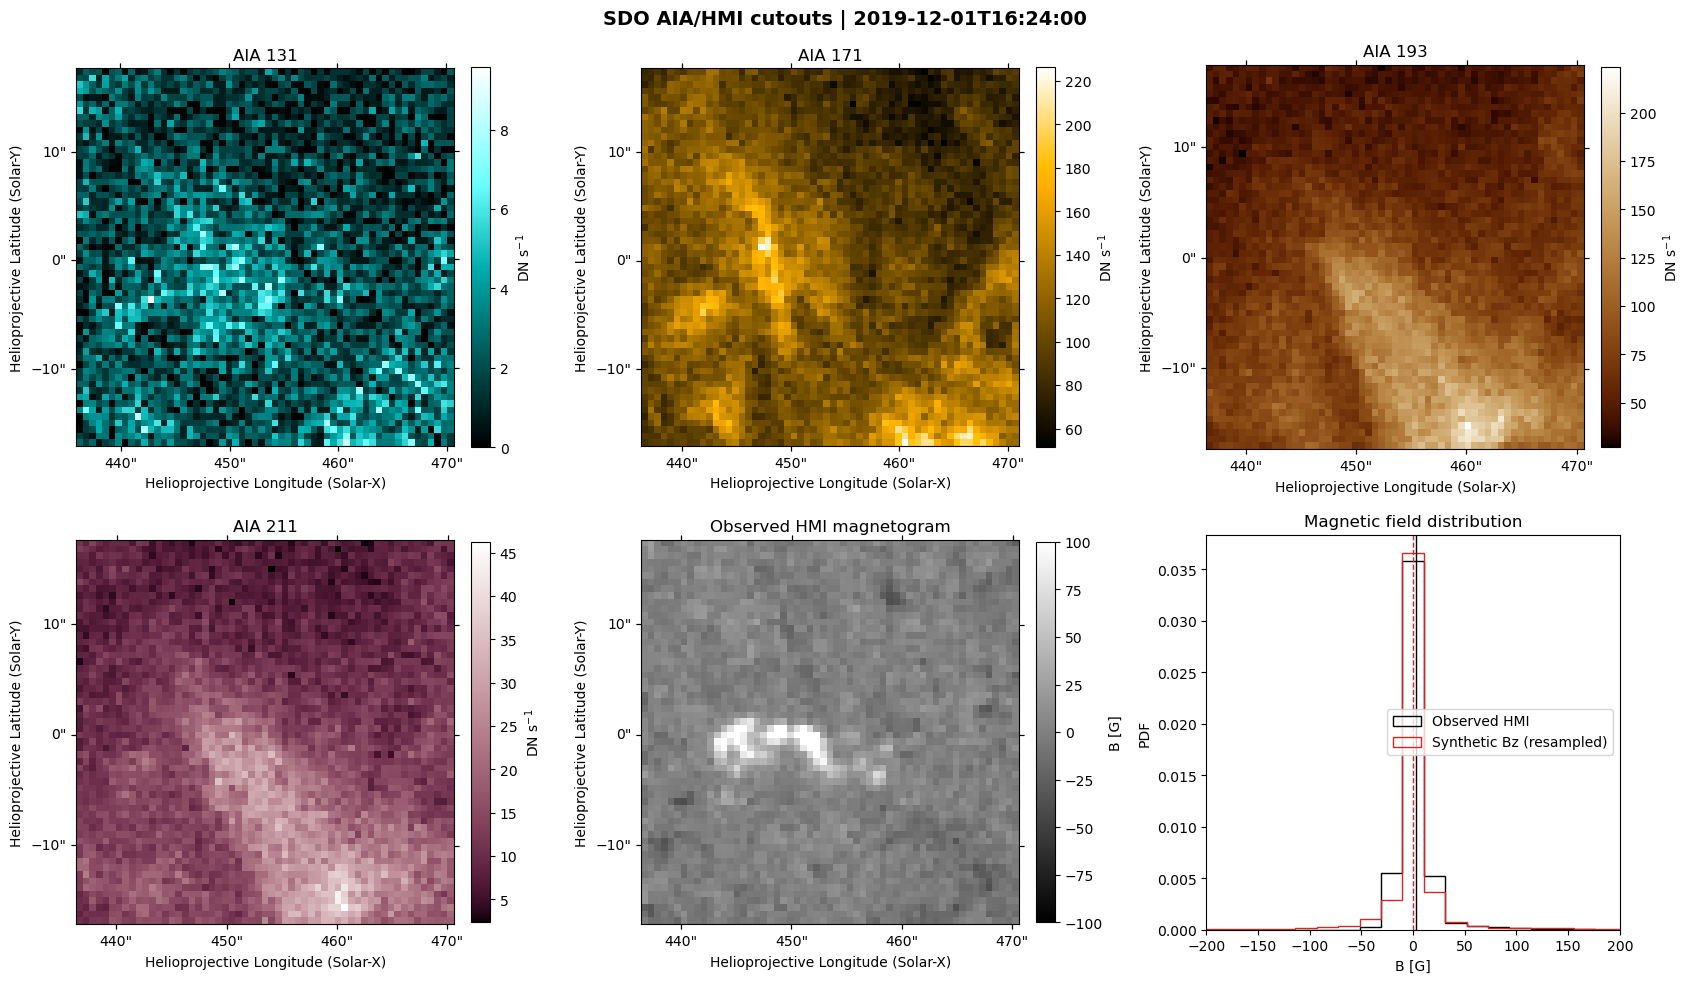

5it [00:05,  1.11s/it]


In [7]:
aia_data_npz = sorted(glob.glob(os.environ['aia_npz_data'] + str_prefix_npz + '*.npz'))

for idx, file in tqdm(enumerate(sorted(aia_data_npz))):
    s = file
    stem = Path(s).stem # gives the filename without directory path and without the final extension
    m = re.search(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", stem) # scans stem for a datetime pattern like YYYY-MM-DDTHH:MM:SS
    dt_str = m.group(0) if m else None
    # Assumes these already exist in the notebook:
    # - dt_str
    # - work_dir
    # - resampled_mag
    #
    # This version plots the observed AIA/HMI cutouts in helioprojective coordinates.

    path_to_cutouts = os.path.join(work_dir, f'SDO_EIS_cutouts_{dt_str}', 'bigger_sdo_cutouts')
    cutout_files = sorted(glob.glob(os.path.join(path_to_cutouts, '*.fits')))

    obs_maps = {}
    for f in cutout_files:
        m = sunpy.map.Map(f)
        obs_maps[int(m.wavelength.value)] = m

    fig = plt.figure(figsize=(17, 10))
    fig.suptitle(f"SDO AIA/HMI cutouts | {dt_str}", fontsize=14, y=0.98, fontweight='bold')

    plot_order = [131, 171, 193, 211]
    aia_cmaps = {
        131: 'sdoaia131',
        171: 'sdoaia171',
        193: 'sdoaia193',
        211: 'sdoaia211',
    }

    # First four panels: AIA
    for ii, ch in enumerate(plot_order, start=1):
        cutout = obs_maps[ch]
        obs_img = cutout.data / cutout.exposure_time.value

        ax = fig.add_subplot(2, 3, ii, projection=cutout.wcs)
        im = ax.imshow(
            obs_img,
            origin='lower',
            interpolation='none',
            cmap=aia_cmaps[ch],
        )
        ax.set_title(f"AIA {ch}")
        ax.coords[0].set_axislabel("Helioprojective Longitude (Solar-X)")
        ax.coords[1].set_axislabel("Helioprojective Latitude (Solar-Y)")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r"DN s$^{-1}$")

    # Fifth panel: observed HMI magnetogram
    hmi_map = obs_maps[6173]
    obs_mag = hmi_map.data.astype(float)

    ax5 = fig.add_subplot(2, 3, 5, projection=hmi_map.wcs)
    im5 = ax5.imshow(
        obs_mag,
        origin='lower',
        interpolation='none',
        cmap='gray',
        vmin=-100,
        vmax=100,
    )
    ax5.set_title("Observed HMI magnetogram")
    ax5.coords[0].set_axislabel("Helioprojective Longitude (Solar-X)")
    ax5.coords[1].set_axislabel("Helioprojective Latitude (Solar-Y)")
    plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04, label="B [G]")

    # Sixth panel: histogram of observed vs synthetic magnetic field
    ax6 = fig.add_subplot(2, 3, 6)

    obs_mag_flat = np.ravel(obs_mag).astype(float)
    syn_mag_flat = np.ravel(resampled_mag).astype(float)

    obs_mag_flat = obs_mag_flat[np.isfinite(obs_mag_flat)]
    syn_mag_flat = syn_mag_flat[np.isfinite(syn_mag_flat)]

    bmax = np.nanmax(np.abs(np.concatenate([obs_mag_flat, syn_mag_flat])))
    bins_mag = np.linspace(-bmax, bmax, 100)

    ax6.hist(
        obs_mag_flat,
        bins=bins_mag,
        histtype='step',
        density=True,
        lw=2,
        color='k',
        label='Observed HMI',
    )
    ax6.hist(
        syn_mag_flat,
        bins=bins_mag,
        histtype='step',
        density=True,
        lw=2,
        ls='--',
        color='tab:red',
        label='Synthetic Bz (resampled)',
    )
    ax6.axvline(np.mean(obs_mag_flat), color='k', lw=1, ls='-')
    ax6.axvline(np.mean(syn_mag_flat), color='tab:red', lw=1, ls='--')
    ax6.set_xlim([-200, 200])
    ax6.set_title("Magnetic field distribution")
    ax6.set_xlabel("B [G]")
    ax6.set_ylabel("PDF")
    ax6.legend()

    plt.tight_layout()
    plt.show()
